loaded object: image_props/hat.png with shape: (2570, 3166, 4)


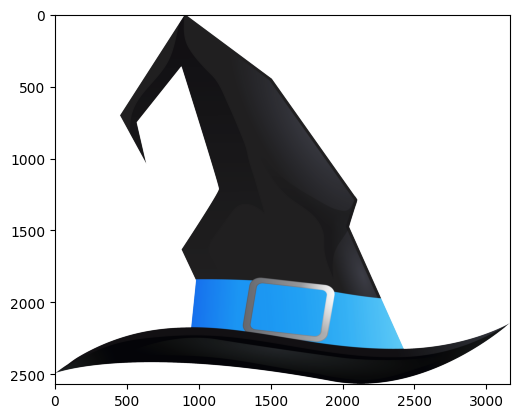

In [1]:
import cv2
import matplotlib.pyplot as plt 
from glob import glob 
import numpy as np 


def load_png_object(file_path: str):
    im = cv2.imread(file_path,cv2.IMREAD_UNCHANGED)
    im_dims = im.shape 
    print(f"loaded object: {file_path} with shape: {im_dims}")
    
    return im, im_dims

def load_frame_data(n_frames: int = 1):
    frame_data = glob("frame_data/*.png")
    frames = []
    np_data = []
    for i, f in enumerate(frame_data): 
        frames.append(cv2.imread(f))
        np_file = f.replace(".png",".txt")
        np_data.append(np.loadtxt(np_file))
        if i>=n_frames: 
            return frames, np_data            

    return frames, np_data


        


object_im, object_dims = load_png_object("image_props/hat.png")
obj_h, obj_w = object_dims[0], object_dims[1]
obj_centre = (obj_w//2,obj_h//2)

plt.imshow(object_im)   

frames, np_data = load_frame_data(n_frames=2)

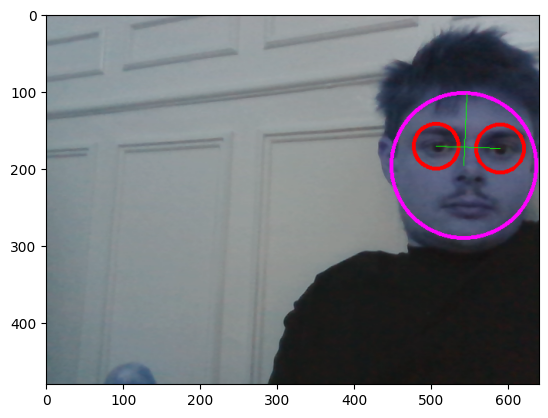

In [2]:
frame = frames[1]
coords = np_data[1]

plt.imshow(frame)

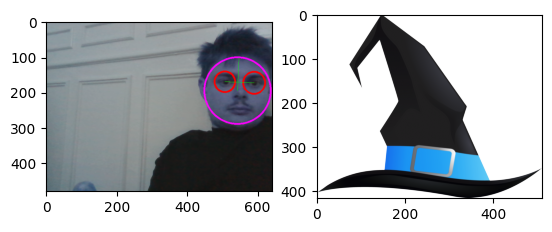

In [3]:
from skimage.transform import rescale
from skimage import io 

frame_dims = frame.shape[0],frame.shape[1]
object_dims = object_im.shape[0], object_im.shape[1]
min_frame_dims = np.min(frame_dims) #always height for webcam type input

width_factor = 0.8*frame_dims[1]/object_dims[1] 
obj_im_rescale = rescale(object_im,width_factor, channel_axis=-1) #currently the image is probably too large 

fix, ax = plt.subplots(1,2)
ax[0].imshow(frame)

ax[1].imshow(obj_im_rescale)

#rescale hat so it is 0.1 of image-width; in principle should be rescaled for face width on the fly later
#object_im = rescale(object_im,)

#io.imsave("hat_rescale.png",obj_im_rescale)


Save smaller version for more efficient compute

In [142]:
obj_im_rescale_uint8 = (obj_im_rescale * 255).astype(np.uint8)
io.imsave("hat_rescaled.png", obj_im_rescale_uint8)


#Make function for blending the two. Only handles negative out of bounds

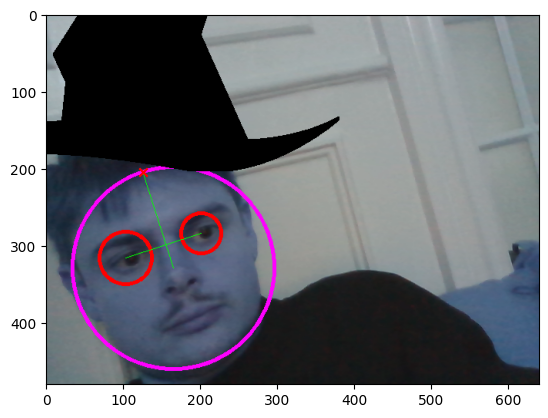

In [ ]:
def insert_hat_on_frame(frame_rgb,obj, coords: tuple[float]):
    #log: fixed so bottom centre is aligned with found face-centre 
    #fixed slicing issues for upper left corner cases 
    #note: not robust to lower/lower right corner cases 
    #TODO: allow slice cropping
    
    frame = frame_rgb.copy()
    im_mask = np.zeros((frame.shape[0],frame.shape[1]))
    hat_mask = obj[:,:,3]>0 #alpha channel: only keep what is actually not transparent
    hat_centre = hat_mask.shape[0]//2, hat_mask.shape[1]//2
    hat_dims = hat_mask.shape[0], hat_mask.shape[1]
    #figure out slices. We just want to place the hat such that the bottom middle pixel aligns with the found coords
    
    slice_start_y = int(coords[1])-hat_dims[0]
    slice_start_x = int(coords[0])-hat_dims[1]//2
    im_mask = np.zeros((frame.shape[0], frame.shape[1]), dtype=bool)
    hat_rgb = obj[:, :, :3]     # discard alpha

    full_hat = np.zeros_like(frame)

    if slice_start_x>0 and slice_start_y>0:  #case: hat is contained in frame 
        im_mask[slice_start_y:slice_start_y+hat_dims[0],slice_start_x:slice_start_x+hat_dims[1]] = hat_mask   
        full_hat[slice_start_y:slice_start_y+hat_dims[0],slice_start_x:slice_start_x+hat_dims[1]] = hat_rgb
        #frame[mask3d] = full_hat[mask3d] 
    elif slice_start_x<0 or slice_start_y<0: #case: upper/left pixels cropped. TODO: make the check formal so we can handle lower-right case as well. 
        lost_pixels_x = np.abs(min([slice_start_x,0]))
        lost_pixels_y = np.abs(min([slice_start_y,0]))
        slice_start_x = max([slice_start_x,0])
        slice_start_y = max([slice_start_y,0])
        im_mask[slice_start_y:slice_start_y+hat_dims[0]-lost_pixels_y,slice_start_x:slice_start_x+hat_dims[1]-lost_pixels_x] = hat_mask[lost_pixels_y:,lost_pixels_x:]
        full_hat[slice_start_y:slice_start_y+hat_dims[0]-lost_pixels_y,slice_start_x:slice_start_x+hat_dims[1]-lost_pixels_x] = hat_rgb[lost_pixels_y:,lost_pixels_x:,:]
    else: #case: need to also slice "outside large boundaries"


    frame[im_mask] = full_hat[im_mask] 

    
    #such that we could handle third case where hat lower/right-region needs to be cropped 
    #elif coords + hat_bounds/2 > im_dims...: 
    
    
    return frame

plt.imshow(insert_hat_on_frame(frame,obj_im_rescale,coords))
plt.scatter(coords[0],coords[1],marker="x",color="r")



Complete function also handling positive out of bounds

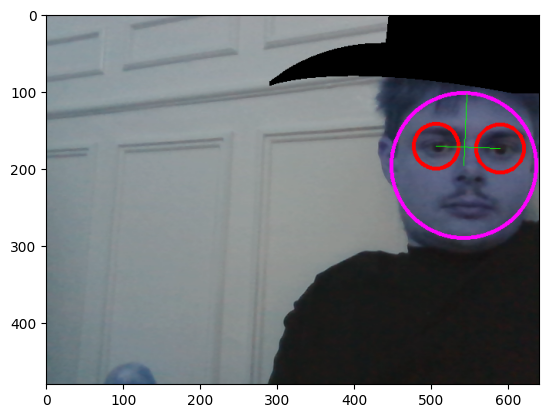

In [4]:
def insert_hat_on_frame(frame_rgb, obj, coords):
    frame = frame_rgb.copy()
    
    Hf, Wf = frame.shape[:2]
    Hh, Wh = obj.shape[:2]

    hat_mask = obj[:, :, 3] > 0
    hat_rgb  = obj[:, :, :3]

    # bottom-center align
    slice_start_y = int(coords[1]) - Hh
    slice_start_x = int(coords[0]) - Wh // 2

    # ---- STEP 1: handle negative starts (crop top/left) ----
    crop_x_left = max(0, -slice_start_x)
    crop_y_top  = max(0, -slice_start_y)

    x1 = max(0, slice_start_x)
    y1 = max(0, slice_start_y)

    # ---- STEP 2: compute end positions BEFORE cropping bottom/right ----
    x2 = x1 + (Wh - crop_x_left)
    y2 = y1 + (Hh - crop_y_top)

    # ---- STEP 3: crop bottom/right if going outside frame ----
    crop_x_right = max(0, x2 - Wf)
    crop_y_bottom = max(0, y2 - Hf)

    # Compute final slice ranges AFTER all cropping
    x2 = x2 - crop_x_right
    y2 = y2 - crop_y_bottom

    # Corresponding crop on hat image
    hat_crop = hat_rgb[crop_y_top:Hh - crop_y_bottom,
                       crop_x_left:Wh - crop_x_right]

    mask_crop = hat_mask[crop_y_top:Hh - crop_y_bottom,
                         crop_x_left:Wh - crop_x_right]

    # ---- STEP 4: insert ----
    im_mask = np.zeros((Hf, Wf), dtype=bool)
    full_hat = np.zeros_like(frame)

    im_mask[y1:y2, x1:x2] = mask_crop
    full_hat[y1:y2, x1:x2] = hat_crop

    frame[im_mask] = full_hat[im_mask]

    return frame

plt.imshow(insert_hat_on_frame(frame,obj_im_rescale,coords))

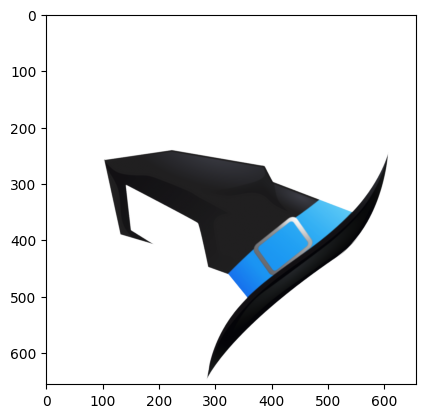

In [ ]:
from skimage.transform import rotate 
# angle in degrees - counter clockwise
rotation_angle = 45

rotation_centre = (obj_im_rescale.shape[0],obj_im_rescale.shape[1]//2)
rotated_img = rotate(obj_im_rescale, rotation_angle,center=rotation_centre,resize=True)
plt.imshow(rotated_img)

In [106]:
obj_im_rescale.shape[0]-77

67

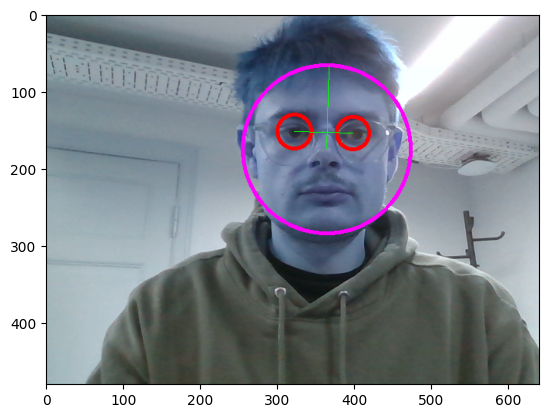

In [65]:
def insert_hat_on_frame(frame, hat_rgba, coords):
    """
    frame: (Hf, Wf, 3) BGR image
    hat_rgba: (Hh, Wh, 4) BGRA image
    coords: (x_center, y_bottom) where the bottom center of the hat should go
    """

    Hf, Wf = frame.shape[:2]
    Hh, Wh = hat_rgba.shape[:2]

    x_center, y_bottom = int(coords[0]), int(coords[1])

    # Compute top-left corner of hat placement
    x1 = x_center - Wh // 2
    y1 = y_bottom - Hh
    x2 = x1 + Wh
    y2 = y1 + Hh

    # Clip if hat goes outside frame
    x1_clip = max(0, x1)
    y1_clip = max(0, y1)
    x2_clip = min(Wf, x2)
    y2_clip = min(Hf, y2)

    if x1_clip >= x2_clip or y1_clip >= y2_clip:
        return frame  # nothing to draw

    # Corresponding coordinates in hat
    hat_x1 = x1_clip - x1
    hat_y1 = y1_clip - y1
    hat_x2 = hat_x1 + (x2_clip - x1_clip)
    hat_y2 = hat_y1 + (y2_clip - y1_clip)

    # Grab region from hat
    hat_region = hat_rgba[hat_y1:hat_y2, hat_x1:hat_x2]

    # Split hat into RGB and alpha
    hat_rgb = hat_region[..., :3].astype(float)
    hat_alpha = (hat_region[..., 3] / 255.0).astype(float)[..., None]  # shape (H,W,1)

    # Grab frame region
    frame_region = frame[y1_clip:y2_clip, x1_clip:x2_clip].astype(float)

    # Blend: out = alpha*hat + (1-alpha)*frame
    out = hat_alpha * hat_rgb + (1 - hat_alpha) * frame_region

    frame[y1_clip:y2_clip, x1_clip:x2_clip] = out.astype(np.uint8)

    return frame

plt.imshow(insert_hat_on_frame(frame,obj_im_rescale,coords))

In [19]:
import numpy as np 

np.random.seed(42)
eye_coords = np.random.randint(low=0,high=10,size=(5,2))
x = eye_coords[:,0]
print(x)
dist_mat = np.abs(x-x[:,None])
left_eye = dist_mat.argmax(axis=0)
print(left_eye)

np.linalg.norm(a[:, None, :] - b[None, :, :], axis=-1)

#faster approach: but don't know if they have scipy installed 
# dists = scipy.spatial.distance.pdist(r, 'cityblock')

[6 7 6 2 7]
[3 3 3 1 3]


NameError: name 'a' is not defined